In [ ]:
import pandas as pd


In [ ]:


df = pd.read_excel('/content/online_retail_II.xlsx')
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.head(200)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
195,489450,22090,PAPER BUNTING RETRO SPOTS,12,2009-12-01 10:36:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
df.isnull().sum()


,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


Remove rows without Customer ID or Description

In [ ]:
df = df.dropna(subset=["Customer ID", "Description"])


Removal of duplicate entries

In [ ]:
df = df.drop_duplicates()


Add extra column for recording total price using Quantity and price

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
df.head(200)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
195,489450,22090,PAPER BUNTING RETRO SPOTS,12,2009-12-01 10:36:00,2.95,16321.0,Australia,35.40
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,-12.75
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,-12.75
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,-12.75


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Customer ID"] = df["Customer ID"].astype(int)


In [ ]:
df["Description"] = df["Description"].str.strip().str.upper()
df["Country"] = df["Country"].str.strip()


In [ ]:
def categorize_product(desc):
    desc = desc.lower()

    if any(word in desc for word in ["food", "cake", "chocolate", "tea", "coffee", "biscuit", "sugar"]):
        return "Food"
    elif any(word in desc for word in ["electronic", "battery", "light", "lamp", "led"]):
        return "Electronics"
    elif any(word in desc for word in ["plate", "cup", "bowl", "knife", "fork", "spoon"]):
        return "Utensils"
    elif any(word in desc for word in ["bag", "box", "basket"]):
        return "Storage"
    else:
        return "Other"


In [ ]:
df["Category"] = df["Description"].astype(str).apply(categorize_product)


In [ ]:
 category_sales = df.groupby("Category")["TotalPrice"].sum().sort_values(ascending=False)
category_sales


,TotalPrice
Category,
Other,5091502.564
Storage,1245787.600
Food,1062967.930
Electronics,693643.310
Utensils,220954.180


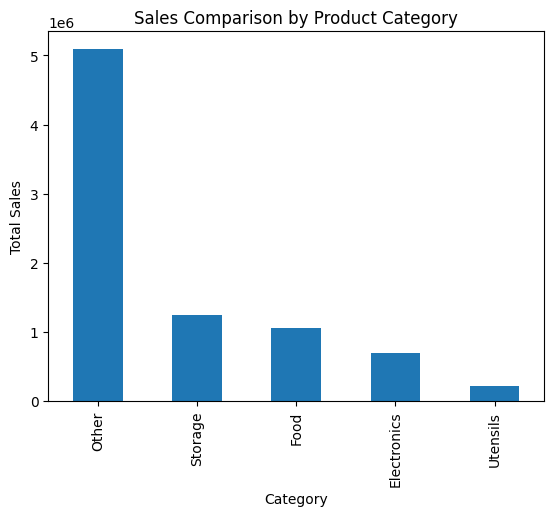

In [ ]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Sales Comparison by Product Category")
plt.show()


In [ ]:
clv = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .reset_index()
      .rename(columns={"TotalPrice": "CLV"})
)


In [ ]:
df = df.merge(clv, on="Customer ID", how="left")


In [ ]:
df.groupby("Category")["CLV"].mean().sort_values(ascending=False)


,CLV
Category,
Food,11982.447870
Utensils,11736.467797
Storage,11400.084359
Other,10665.888209
Electronics,10214.371276


In [ ]:
top_customers = clv.sort_values("CLV", ascending=False).head(10)
top_customers


,Customer ID,CLV
4254,18102,341776.73
1662,14646,243853.05
1291,14156,183163.55
1869,14911,137710.76
957,13694,128172.42
3807,17511,83760.60
1983,15061,82162.74
3178,16684,75610.17
511,13089,55801.73
3228,16754,54558.18


In [ ]:
df.head(200)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Category,CLV
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,Electronics,1187.08
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,Electronics,1187.08
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,Electronics,1187.08
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,Other,1187.08
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,Storage,1187.08
...,...,...,...,...,...,...,...,...,...,...,...
195,489450,22090,PAPER BUNTING RETRO SPOTS,12,2009-12-01 10:36:00,2.95,16321,Australia,35.40,Other,34.80
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom,-12.75,Other,0.00
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom,-12.75,Other,0.00
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom,-12.75,Other,0.00


In [ ]:
categories = [
    "Electronics", "Home & Living", "Kitchen & Dining",
    "Clothing & Apparel", "Accessories",
    "Beauty & Personal Care", "Health & Wellness",
    "Sports & Outdoors", "Toys & Games",
    "Office & Stationery", "Automotive",
    "Food & Beverages", "Books & Media",
    "Pet Supplies", "Baby & Kids",
    "Furniture", "Tools & Hardware",
    "Jewelry & Luxury", "Garden & Outdoor",
    "Other"
]

In [ ]:
def initial_category(desc):
    desc = str(desc).lower()

    if any(w in desc for w in ["led", "battery", "lamp", "light"]):
        return "Electronics"
    elif any(w in desc for w in ["plate", "bowl", "cup", "spoon", "knife"]):
        return "Kitchen & Dining"
    elif any(w in desc for w in ["sofa", "chair", "table"]):
        return "Furniture"
    elif any(w in desc for w in ["toy", "game", "puzzle"]):
        return "Toys & Games"
    elif any(w in desc for w in ["pen", "paper", "notebook"]):
        return "Office & Stationery"
    elif any(w in desc for w in ["necklace", "ring", "bracelet"]):
        return "Jewelry & Luxury"
    elif any(w in desc for w in ["plant", "garden"]):
        return "Garden & Outdoor"
    else:
        return "Other"

df["Category"] = df["Description"].apply(initial_category)


In [ ]:
X = df["Description"]
y = df["Category"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.99986610348983
                     precision    recall  f1-score   support

        Electronics       1.00      1.00      1.00      5160
          Furniture       1.00      0.99      1.00       311
   Garden & Outdoor       1.00      1.00      1.00      1694
   Jewelry & Luxury       1.00      1.00      1.00      1724
   Kitchen & Dining       1.00      1.00      1.00      3380
Office & Stationery       1.00      1.00      1.00      4151
              Other       1.00      1.00      1.00     65012
       Toys & Games       1.00      1.00      1.00       721

           accuracy                           1.00     82153
          macro avg       1.00      1.00      1.00     82153
       weighted avg       1.00      1.00      1.00     82153



In [ ]:
df["ML_Category"] = model.predict(
    vectorizer.transform(df["Description"])
)


In [ ]:
category_sales = (
    df.groupby("ML_Category")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

category_sales


,TotalPrice
ML_Category,
Other,6543386.424
Electronics,702255.960
Office & Stationery,388042.990
Kitchen & Dining,281218.400
Garden & Outdoor,149557.150
Jewelry & Luxury,131873.570
Toys & Games,70170.180
Furniture,48350.910


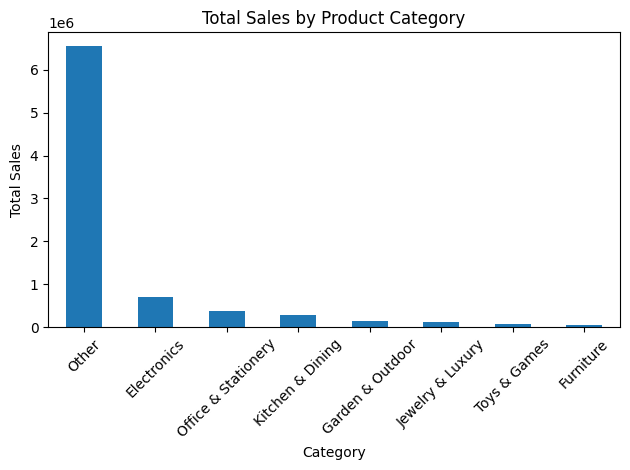

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
category_sales.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [ ]:
df = df.dropna(subset=['Description', 'Category'])

X = df['Description']
y = df['Category']


In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_tfidf = tfidf.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


                     precision    recall  f1-score   support

        Electronics       1.00      1.00      1.00      5160
          Furniture       1.00      0.99      1.00       311
   Garden & Outdoor       1.00      1.00      1.00      1694
   Jewelry & Luxury       1.00      1.00      1.00      1724
   Kitchen & Dining       1.00      1.00      1.00      3380
Office & Stationery       1.00      1.00      1.00      4151
              Other       1.00      1.00      1.00     65012
       Toys & Games       1.00      1.00      1.00       721

           accuracy                           1.00     82153
          macro avg       1.00      1.00      1.00     82153
       weighted avg       1.00      1.00      1.00     82153



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Clean description
df = df.dropna(subset=['Description'])
df['Description'] = df['Description'].str.lower()

# TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['Description'])

# KMeans (you can change n_clusters)
kmeans = KMeans(n_clusters=8, random_state=42)

df['ML_Category'] = kmeans.fit_predict(X)


In [ ]:
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(8):
    print(f"\nCluster {i}:")
    for ind in order_centroids[i, :10]:
        print(terms[ind], end=' ')



Cluster 0:
metal red sign blue white christmas design retrospot water hot 
Cluster 1:
cake cases fairy stand 60 pack 72 ceramic pink teatime 
Cluster 2:
heart holder light hanging white decoration small large zinc glass 
Cluster 3:
set paper piece red spotty lights doilies retrospot candles baking 
Cluster 4:
jumbo bag storage white red paisley retrospot pink strawberry suki 
Cluster 5:
bag lunch charlotte red design spotty retrospot suki woodland shoulder 
Cluster 6:
vintage tin plasters paisley jack union christmas red set bag 
Cluster 7:
box pink trinket ceramic lunch strawberry recipe cutlery design felt 

In [ ]:
sales_by_ml = df.groupby("ML_Category")["TotalPrice"].sum().sort_values(ascending=False)

print(sales_by_ml)


ML_Category
0    4606373.994
3     774033.210
2     768278.420
7     651688.310
6     486354.640
1     400643.320
4     335932.300
5     291551.390
Name: TotalPrice, dtype: float64
